# Exercise 13.4

In [6]:
import pandas as pd
stress = pd.read_csv("stress.csv")
strain = pd.read_csv("strain.csv")

### *Data Spliting into train and test set*

In [7]:
from sklearn.model_selection import train_test_split

# Note: scikit-learn uses 'train_size' instead of 'fraction'
stress_train, stress_test, strain_train, strain_test = train_test_split(stress, strain, train_size=0.7, random_state=42)
X_train = strain_train.values
X_test  = strain_test.values
y_train = stress_train.values
y_test  = stress_test.values

### *kNN_regression with k=3*

In [8]:
import numpy as np
from numpy import ndarray, empty, argsort, argmax, bincount
from scipy.spatial import distance_matrix

def knn_regression(X_train, y_train, X_test, k):
    dist = distance_matrix(X_test, X_train)
    y_pred = np.zeros((X_test.shape[0], y_train.shape[1]))

    for i, d in enumerate(dist):
        idx = np.argsort(d)[:k]
        neighbors = y_train[idx]
        y_pred[i] = neighbors.mean(axis=0)

    return y_pred
    
predicted_stress = knn_regression(X_train, y_train, X_test, k=3)

strain_df = pd.DataFrame(
    X_test[:, 1:],
    columns=["0°C", "400°C", "600°C"]
)
predicted_stress_df = pd.DataFrame(
    predicted_stress[:, 1:],
    columns=["0°C", "400°C", "600°C"]
)

print(f"Test Strain \n{strain_df.head()}") #printing the first 5 rows
print(f"\nPredicted Stress \n{predicted_stress_df.head()}") #printing the first 5 rows

Test Strain 
        0°C     400°C     600°C
0  0.008216  0.008148  0.008177
1  0.019498  0.019378  0.019551
2  0.018034  0.017953  0.017659
3  0.012963  0.013120  0.012873
4  0.007992  0.008267  0.008085

Predicted Stress 
         0°C      400°C      600°C
0  61.794297  47.873287  25.359912
1  62.675449  50.269222  24.139598
2  62.707425  51.041994  24.860529
3  61.199023  47.917730  24.566009
4  59.635883  46.919656  24.605489


### *Mean Square Error Function*

In [9]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

### *Calculating traing and test MSE for range of k values*

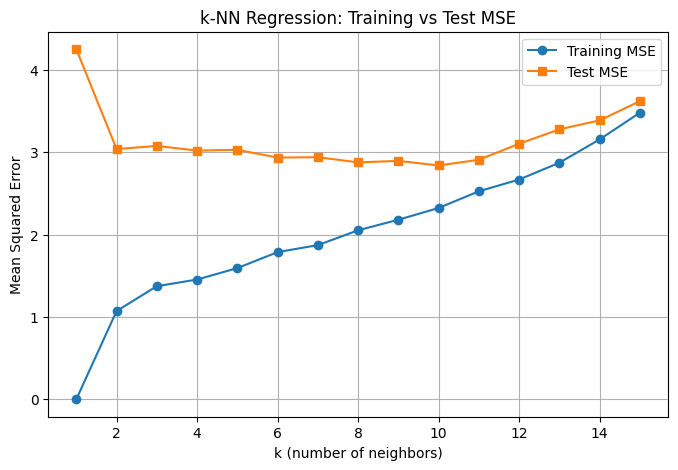

In [10]:
import matplotlib.pyplot as plt
k_values = range(1, 16)   # try k = 1 to 15
train_mse = []
test_mse = []

for k in k_values:
    # Training prediction (predict X_train from X_train)
    y_train_pred = knn_regression(X_train, y_train, X_train, k)
    train_mse.append(mse(y_train, y_train_pred))

    # Test prediction
    y_test_pred = knn_regression(X_train, y_train, X_test, k)
    test_mse.append(mse(y_test, y_test_pred))


plt.figure(figsize=(8,5))
plt.plot(k_values, train_mse, marker='o', label='Training MSE')
plt.plot(k_values, test_mse, marker='s', label='Test MSE')

plt.xlabel('k (number of neighbors)')
plt.ylabel('Mean Squared Error')
plt.title('k-NN Regression: Training vs Test MSE')
plt.legend()
plt.grid(True)
plt.show()

##### *The training MSE increases with k, while the test MSE decreases initially and reaches its minimum at k = 10. For k > 10, the test MSE increases again due to oversmoothing. Therefore, k = 10 provides the best generalization performance and is chosen as the optimal number of neighbors.*


### *Redoing k-NN regression for k=10*

In [11]:
predicted_stress = knn_regression(X_train, y_train, X_test, k=10)
print(f"Test Strain \n{strain_df.head()}") #printing the first 5 rows
print(f"\nPredicted Stress \n{predicted_stress_df.head()}") #printing the first 5 rows

Test Strain 
        0°C     400°C     600°C
0  0.008216  0.008148  0.008177
1  0.019498  0.019378  0.019551
2  0.018034  0.017953  0.017659
3  0.012963  0.013120  0.012873
4  0.007992  0.008267  0.008085

Predicted Stress 
         0°C      400°C      600°C
0  61.794297  47.873287  25.359912
1  62.675449  50.269222  24.139598
2  62.707425  51.041994  24.860529
3  61.199023  47.917730  24.566009
4  59.635883  46.919656  24.605489


In [12]:
#*******************************************************
#*******************************************************

# Exercise 13.6

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.interpolate import LSQUnivariateSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [14]:
# 1. LOAD DATA
strain = pd.read_csv("strain.csv")
stress = pd.read_csv("stress.csv")
strain = strain[[c for c in strain.columns if not c.startswith('Unnamed')]]
stress = stress[[c for c in stress.columns if not c.startswith('Unnamed')]]

### *Regression Using Quadratic Spline*

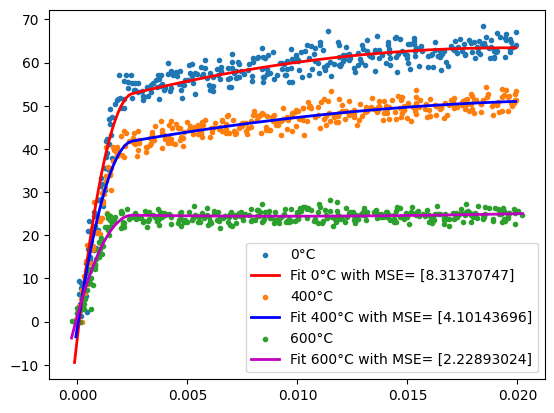

In [15]:
# regression using quadratic spline
# inner support point manually chosen to be at the yield point
inner_support_points_x = [0.0025]

temp=[0,400,600]; c=["r","b","m"]
for i in [0,1,2]:
    idx=np.argsort(strain.values[:, i])
    x=(strain.values[:, i][idx])
    y=(stress.values[:, i][idx])
    

    spl = LSQUnivariateSpline(x, y, inner_support_points_x, k=2)
    MSE = ((y - spl(x))**2).sum() / y.shape
    plt.scatter(x, y, marker='.', label=f'{temp[i]}°C')
    plt.plot(x, spl(x), lw=2, c=c[i], label=f'Fit {temp[i]}°C with MSE= {MSE}')

plt.legend()
plt.show()


### *Polynomial Regression (Degree 3)*

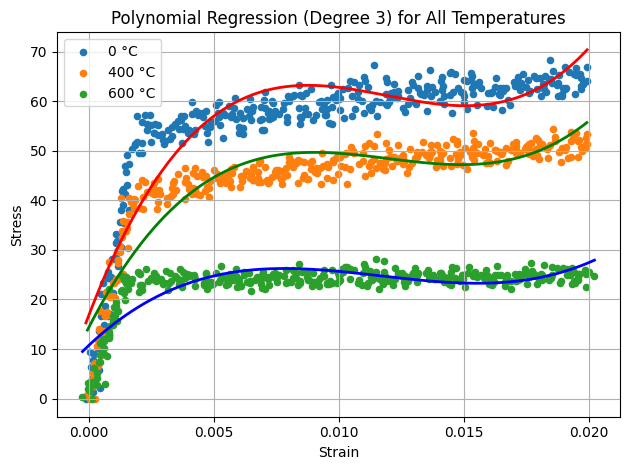

In [16]:
temp=[0,400,600]; color=["r","g","b"]
for i in [0,1,2]:
    idx=np.argsort(strain.values[:, i])
    x=(strain.values[:, i][idx]).reshape(-1, 1)
    y=(stress.values[:, i][idx])
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(x)
    model = LinearRegression()
    model.fit(X_poly, y)

    # Smooth grid for plotting
    x_grid = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)
    X_grid_poly = poly.transform(x_grid)
    y_pred = model.predict(X_grid_poly)

    # Plot data + fit
    plt.scatter(x, y, s=20, label=f"{temp[i]} °C")
    plt.plot(x_grid, y_pred, linewidth=2, c=color[i])
    

plt.xlabel("Strain")
plt.ylabel("Stress")
plt.title("Polynomial Regression (Degree 3) for All Temperatures")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()